<a href="https://colab.research.google.com/github/navyapalam/fakedocumentdetection/blob/main/fakedocumentdetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
os.makedirs("/content/dataset/genuine", exist_ok=True)
os.makedirs("/content/dataset/forged", exist_ok=True)

print("Dataset folders created!")

Dataset folders created!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving real image3.jpg to real image3.jpg
Saving real image2.jpg to real image2.jpg
Saving real image1.jpg to real image1 (1).jpg


In [ ]:
import shutil

for filename in uploaded.keys():
    shutil.move(filename, "/content/dataset/genuine/" + filename)

print("Genuine images uploaded!")

Genuine images uploaded!


In [ ]:
uploaded = files.upload()

Saving fake image2.jpg to fake image2 (1).jpg
Saving fake image3.jpg to fake image3 (1).jpg
Saving fake image1.jpg to fake image1 (1).jpg


In [ ]:
for filename in uploaded.keys():
    shutil.move(filename, "/content/dataset/forged/" + filename)

print("Forged images uploaded successfully!")

Forged images uploaded successfully!


In [ ]:
import os

print("Genuine:", os.listdir("/content/dataset/genuine"))
print("Forged:", os.listdir("/content/dataset/forged"))

Genuine: ['real image3.jpg', 'real image2.jpg', 'real image1 (1).jpg']
Forged: ['fake image3 (1).jpg', 'fake image1 (1).jpg', 'fake image1.jpg', 'fake image2 (1).jpg']


In [ ]:
IMG_SIZE = 128

def load_images(folder, label):
    images = []
    labels = []

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        img = cv2.imread(path)

        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            images.append(img)
            labels.append(label)

    return images, labels


# Genuine = 0
genuine_images, genuine_labels = load_images(
    "/content/dataset/genuine", 0
)

# Forged = 1
forged_images, forged_labels = load_images(
    "/content/dataset/forged", 1
)


X = np.array(genuine_images + forged_images)
y = np.array(genuine_labels + forged_labels)

X = X.astype("float32") / 255.0

print("Total images:", len(X))
print("Image shape:", X.shape)
print("Labels:", y.shape)

Total images: 7
Image shape: (7, 128, 128, 3)
Labels: (7,)


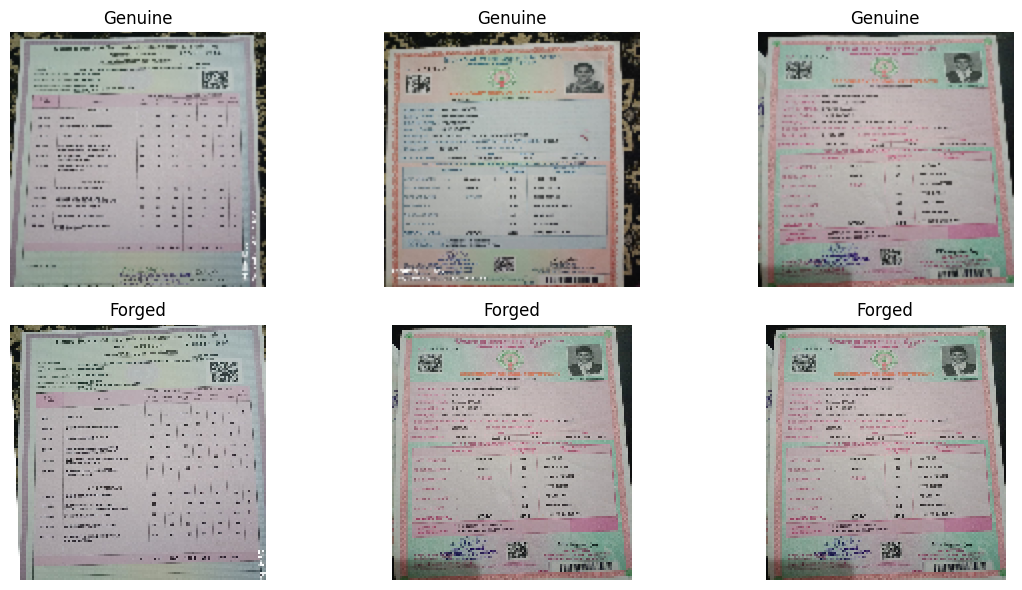

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(min(6, len(X))):

    plt.subplot(2, 3, i + 1)
    plt.imshow(X[i])

    if y[i] == 0:
        plt.title("Genuine")
    else:
        plt.title("Forged")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 5
Testing images: 2


In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation="relu",
           input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.7151 - val_accuracy: 0.0000e+00 - val_loss: 0.7792
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step - accuracy: 0.5000 - loss: 0.8571 - val_accuracy: 1.0000 - val_loss: 0.4108
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.5000 - loss: 0.9323 - val_accuracy: 1.0000 - val_loss: 0.6214
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.0000e+00 - loss: 0.8951 - val_accuracy: 1.0000 - val_loss: 0.6708
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5000 - loss: 0.7176 - val_accuracy: 1.0000 - val_loss: 0.6764
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.7500 - loss: 0.6551 - val_accuracy: 1.0000 - val_loss: 0.6643
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.7500 - loss: 0.6373 - val_accuracy: 0.0000e+00 - val_loss: 0.7079
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.2500 - loss: 0.6973 - val_accuracy: 0.0000e+0

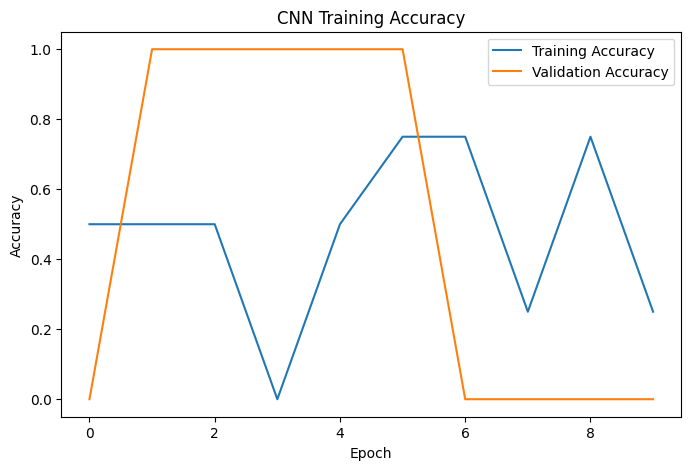

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training Accuracy")
plt.legend()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", round(accuracy * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5000 - loss: 0.7227
Test Accuracy: 50.0 %


In [ ]:
y_probability = model.predict(X_test)

y_pred = (y_probability >= 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
Accuracy : 50.0 %
Precision: 0.0 %
Recall   : 0.0 %
F1 Score : 0.0 %


In [1]:
from google.colab import files

uploaded = files.upload()

Saving real image1.jpg to real image1.jpg


In [5]:
import cv2
import numpy as np
import tensorflow as tf

# Model definition (copied from hnnUe-4nOvX3)
# NOTE: This will create an *untrained* model.
# For accurate predictions, ensure the cells defining and training the model
# (hnnUe-4nOvX3 and wuiwQXerO1g-) are executed before this cell,
# or save and load the trained model.
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

img = cv2.resize(img, (128,128))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = img.astype("float32") / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)[0][0]

if prediction >= 0.5:
    print("Result: FORGED DOCUMENT")
    print("Confidence:", round(prediction * 100, 2), "%")
else:
    print("Result: GENUINE DOCUMENT")
    print("Confidence:", round((1 - prediction) * 100, 2), "%")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
Result: GENUINE DOCUMENT
Confidence: 50.11 %
